In [2]:
!pip install --upgrade qdrant-client

import sys

sys.path.append('/kaggle/input/datasets/enol00/web-scrapper-utils')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 15.7 MB/s eta 0:00:00


In [4]:
from torch.utils.data import DataLoader
from transformers import pipeline, AutoModel, AutoImageProcessor
from qdrant_client import QdrantClient
from qdrant_client.models import PointStruct, VectorParams, Distance
from dotenv import load_dotenv
import os, torch, re, json
from otomoto_ds import OtomotoIterableDataset
from uuid import uuid4
from utils import *
from PIL import Image
from sklearn.metrics import pairwise_distances
from umap import UMAP
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
load_dotenv(dotenv_path='/kaggle/input/datasets/enol00/secret/.env')

COLLECTION_NAME = "cars"

api_key = os.getenv('QDRANT_API_KEY')
api_url = os.getenv('QDRANT_URL')

client = QdrantClient(
    api_key=api_key,
    url=api_url,
)

if not client.collection_exists(COLLECTION_NAME):
    client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(
            size=768,
            distance=Distance.COSINE
        )
    )

In [ ]:
llm_model_name = "Qwen/Qwen2.5-3B-Instruct"

llm = pipeline(
    "text-generation",
    model=llm_model_name,
    dtype=torch.float16,
    device_map="auto"
)

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "facebook/dinov2-base"

processor = AutoImageProcessor.from_pretrained(model_id)
embedder = AutoModel.from_pretrained(model_id).to(device)

embedder.eval()

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

In [7]:
cars_ds = OtomotoIterableDataset(start_page=5, max_pages=12)

dataloader = DataLoader(
    dataset=cars_ds,
    batch_size=2,
    collate_fn=collate_fn
)

In [8]:
def llm_parse(user_content: list[str]) -> list | None:
    with torch.no_grad():
        output = llm(
            [build_prompt(content) for content in user_content],
            temperature=0.0,
            do_sample=False,
            max_new_tokens=512,
            return_full_text=False
        )

    raw_responses = [out[0]["generated_text"] for out in output]

    cleaned_response = [re.sub(r"^```(?:json)?\s*", "", response) for response in raw_responses]
    cleaned_response = [re.sub(r"\s*```$", "", response).strip() for response in cleaned_response]

    try:
        return [json.loads(response) for response in cleaned_response]

    except json.JSONDecodeError:
        return None

In [9]:
def vit_parse(imgs_batch: list[list[Image]]) -> np.ndarray:
    flat_imgs = [img for sublist in imgs_batch for img in sublist]

    inputs = processor(images=flat_imgs, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = embedder(**inputs)

        cls_embeddings = outputs.last_hidden_state[:, 0, :]

        normalized = cls_embeddings / torch.norm(cls_embeddings, dim=-1, keepdim=True)

    return normalized.cpu().numpy().tolist()

In [ ]:
for batch_images, batch_html, batch_url in dataloader:

    batch_metadata = llm_parse(batch_html)
    embeddings = vit_parse(batch_images)

    for metadata, url in zip(batch_metadata, batch_url):
        metadata['url'] = url

    embeddings = iter(vit_parse(batch_images))

    records = [
        PointStruct(
            id=str(uuid4()),
            vector=next(embeddings),
            payload=metadata
        )

        for metadata, image_group in zip(batch_metadata, batch_images)
        for _ in image_group
    ]

    if records:
        client.upsert(
            collection_name=COLLECTION_NAME,
            points=records
        )

In [21]:
records = client.scroll(
    collection_name=COLLECTION_NAME,
    limit=4400,
    with_vectors=True,
    with_payload=["brand", "model", "body_type", 'url']
)[0]

vectors = np.stack([record.vector for record in records])
ids = np.array([record.payload['url'] for record in records], dtype="U64")
metadata = np.array([record.payload['brand'] + record.payload["model"] + record.payload['body_type'] for record in records], dtype="U64")

In [22]:
def evaluate_retrieval(query_vecs, query_urls, query_models, k=5):
    dist_matrix = pairwise_distances(query_vecs, metric="cosine")

    np.fill_diagonal(dist_matrix, np.inf)

    mrr_list = []
    hit_at_k_list = []
    precision_at_k_model_list = []

    valid_queries_count = 0

    for i in range(len(query_vecs)):
        target_url = query_urls[i]
        target_model = query_models[i]

        other_photos_same_offer = np.where(query_urls == target_url)[0]
        other_photos_same_offer = [
            idx for idx in other_photos_same_offer if idx != i
        ]

        if len(other_photos_same_offer) == 0:
            continue

        valid_queries_count += 1

        sorted_indices = np.argsort(dist_matrix[i])

        matches_url = query_urls[sorted_indices] == target_url
        first_match_rank = (
            np.where(matches_url)[0][0] + 1
        )  

        mrr_list.append(1.0 / first_match_rank)

        hit_at_k_list.append(1 if first_match_rank <= k else 0)

        top_k_models = query_models[sorted_indices[:k]]
        precision_model = np.mean(top_k_models == target_model)
        precision_at_k_model_list.append(precision_model)

    return {
        "valid_queries": valid_queries_count,
        "MRR_offer": np.mean(mrr_list),
        f"Hit@{k}_offer": np.mean(hit_at_k_list),
        f"Precision@{k}_model": np.mean(precision_at_k_model_list),
    }

In [23]:
results = evaluate_retrieval(
    query_vecs = vectors,
    query_urls = ids,
    query_models = metadata
)

for metric in results:
    print(f'{metric} = {results[metric]}\n')

valid_queries = 4399

MRR_offer = 0.6316163743880071

Hit@5_offer = 0.6542395999090702

Precision@5_model = 0.30243237099340764



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_58/3175941615.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  url_spreads = df_filtered.groupby('url').apply(calculate_spread)


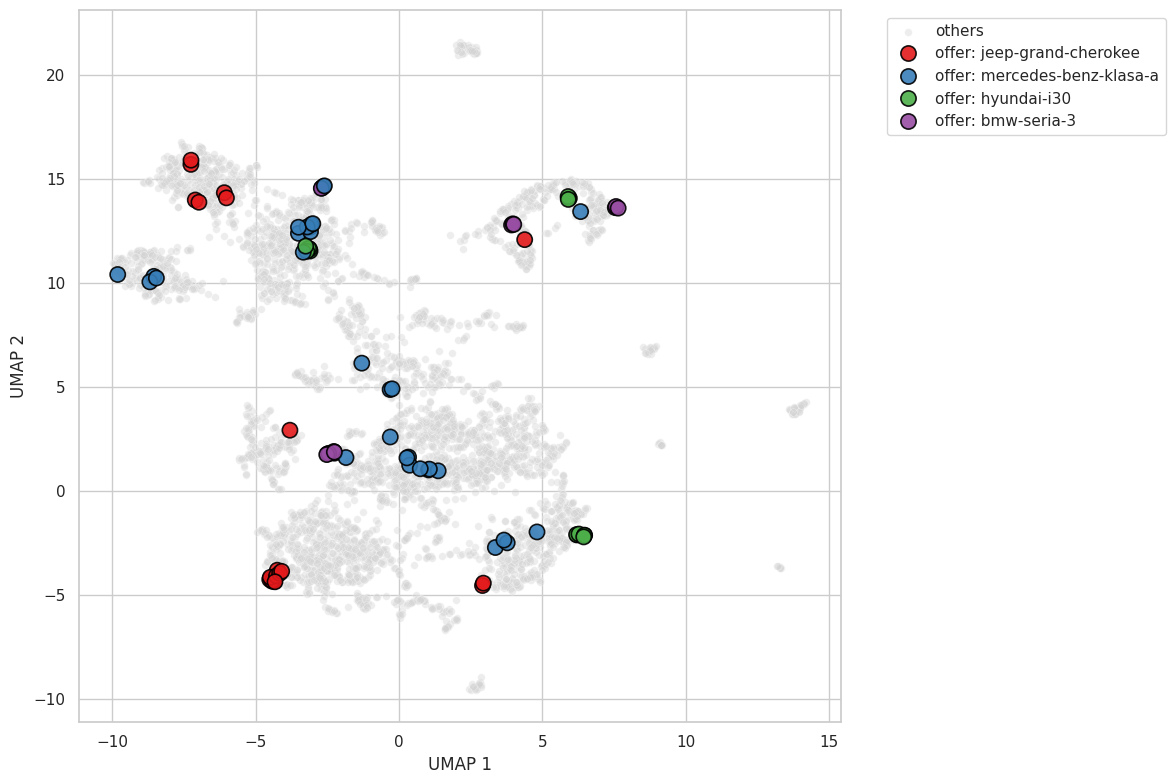

In [25]:
reducer = UMAP(
    n_neighbors=15,
    min_dist=0.5,
    metric='cosine',
    random_state=42
)

embedding_2d = reducer.fit_transform(vectors)

df = pd.DataFrame({
    'UMAP 1': embedding_2d[:, 0],
    'UMAP 2': embedding_2d[:, 1],
    'url': ids
})


url_counts = df['url'].value_counts()

MIN_PHOTOS = 15
valid_urls = url_counts[url_counts >= MIN_PHOTOS].index

df_filtered = df[df['url'].isin(valid_urls)]


def calculate_spread(group):
    return np.std(group['UMAP 1']) + np.std(group['UMAP 2'])


url_spreads = df_filtered.groupby('url').apply(calculate_spread)

selected_urls = url_spreads.nlargest(4).index.tolist()


def assign_label(url):
    if url in selected_urls:
        link = f"offer: {url.split('/')[-1]}"
        return link[:link.find("-ID")]
    return "others"


df['display_group'] = df['url'].apply(assign_label)

df_background = df[df['display_group'] == "others"]
df_highlighted = df[df['display_group'] != "others"]

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_background, x='UMAP 1', y='UMAP 2',
    color='#d3d3d3', alpha=0.4, s=30, label="others"
)

sns.scatterplot(
    data=df_highlighted, x='UMAP 1', y='UMAP 2',
    hue='display_group', palette='Set1', s=120, alpha=0.9,
    edgecolor='black', linewidth=1.2
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()